# contact-CLASP · clasp_l3 — the headline: precision@L vs Neff/L

**The novel axis.** DCA needs many diverse sequences; attention is computed from one. So as alignment depth (**Neff/L**) drops, DCA should fall while attention stays flat. We subsample the MSA to sweep Neff/L and plot both.

In [1]:
import os, sys
ROOT = os.path.abspath("")
while ROOT != os.path.dirname(ROOT) and not os.path.isdir(os.path.join(ROOT, "common")):
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)                          # for `import common`
sys.path.insert(0, os.path.join(ROOT, "clasp"))   # for `import clasp_common`
DATA = os.path.join(ROOT, "data")
print("repo root:", ROOT)

repo root: C:\Users\soura\code\2026\xai-starter


In [2]:
import numpy as np
from clasp_common import (load_demo_chain, esm_attention_contacts, simulate_msa,
                          mfdca_contacts, neff, precision_at_l)
seq, coords, true = load_demo_chain(cache_dir=DATA)
L = len(seq)
attn_p = precision_at_l(esm_attention_contacts(seq), true)
full = simulate_msa(seq, true, n_seqs=600)
rows = []
for frac in (1.0, 0.5, 0.25, 0.1, 0.05):
    sub = full[: max(5, int(600 * frac))]
    rows.append((neff(sub) / L, precision_at_l(mfdca_contacts(sub), true)))
rows.sort()
nl, dca_p = zip(*rows)
print('Neff/L :', [round(x, 2) for x in nl])
print('DCA P@L:', [round(x, 2) for x in dca_p])
print('attention P@L (flat):', round(attn_p, 3))

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Neff/L : [0.52, 0.99, 2.37, 4.24, 8.44]
DCA P@L: [0.29, 0.45, 0.76, 0.78, 0.78]
attention P@L (flat): 0.069


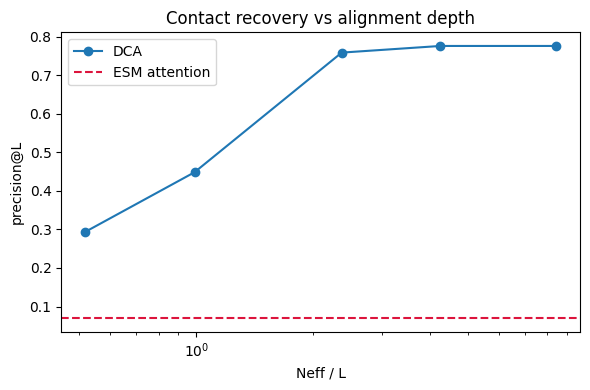

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.plot(nl, dca_p, 'o-', label='DCA')
plt.axhline(attn_p, ls='--', c='crimson', label='ESM attention')
plt.xscale('log'); plt.xlabel('Neff / L'); plt.ylabel('precision@L')
plt.title('Contact recovery vs alignment depth'); plt.legend(); plt.tight_layout(); plt.show()

### Things to experiment with
- This is the figure the project turns on. With real MSAs, the crossover point (where attention overtakes DCA) is the headline result.
- Bin by identity-to-pretraining too (see `CLAUDE.md`).